# Análisis de datos exploratorio

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Cargar datos

In [2]:
%%time
# Estructura de datos
data: dict[str, dict[str, np.ndarray]] = {}

target_folders = ["Mouse", "NMR"]

# Extraer archivos .npy
for folder_name in target_folders:
    sub_folder = Path("..") / folder_name

    if sub_folder.is_dir():
        data[sub_folder.name] = {
            file.stem: np.load(file) for file in sub_folder.glob("*.npy")
        }

# Obtener información sobre valores nulos, valores infinitos, tipo de dato y forma
for d in data:
    for lipid in data[d]:
        array = data[d][lipid]
        nans = np.isnan(array).sum()
        infs = np.isinf(array).sum()
        dtype = array.dtype
        shape = array.shape
        print(
            f"Array {d} {lipid}: nans={nans}, infs={infs}, dtype={dtype}, shape={shape}"
        )

Array Mouse g3_DPSM_heads_resids: nans=0, infs=0, dtype=int64, shape=(342,)
Array Mouse g3_DPSM_tails: nans=0, infs=0, dtype=float64, shape=(342, 401, 201)
Array Mouse artificial_volume: nans=0, infs=0, dtype=float64, shape=(1,)
Array Mouse g3_DPSM_heads: nans=0, infs=0, dtype=float64, shape=(342, 401, 201)
Array Mouse g3_CHOL_head: nans=0, infs=0, dtype=float64, shape=(170, 401, 201)
Array Mouse g3_CHOL_head_resids: nans=0, infs=0, dtype=int64, shape=(170,)
Array Mouse g3_DPSM_tails_resids: nans=0, infs=0, dtype=int64, shape=(342,)
Array Mouse g3_CHOL_body_resids: nans=0, infs=0, dtype=int64, shape=(170,)
Array Mouse g3_CHOL_body: nans=0, infs=0, dtype=float64, shape=(170, 401, 201)
Array NMR g3_DPSM_heads_resids: nans=0, infs=0, dtype=int64, shape=(170,)
Array NMR g3_DPSM_tails: nans=0, infs=0, dtype=float64, shape=(170, 401, 201)
Array NMR artificial_volume: nans=0, infs=0, dtype=float64, shape=(1,)
Array NMR g3_DPSM_heads: nans=0, infs=0, dtype=float64, shape=(170, 401, 201)
Array 

No existen valores nulos. Sin embargo, todos los arrays que son `resids` son en realidad índices. Además, `artificial_volume` solamente es un único valor. Este último representa al volumen de caja; los datos provistos ya están normalizados por éste. 

In [3]:
# Ejemplo resids
data["Mouse"]["g3_CHOL_body_resids"][:10]

array([ 2,  5,  6,  7,  8, 14, 16, 17, 22, 24])

In [4]:
# Artificial volume
data["Mouse"]["artificial_volume"], data["NMR"]["artificial_volume"]

(array([1052298.72674169]), array([886284.35260828]))

En la carga anterior de los datos se destaca con los `resids` tienen el mismo `shape` para cada tipo de lípido. Sin embargo, se puede ver que los `resids` son el mismo array para cada tipo.

In [5]:
for d in data:
    print(f"{d} DPSM resids iguales:", (data[d]["g3_DPSM_heads_resids"] == data[d]["g3_DPSM_tails_resids"]).all())
    print(f"{d} CHOL resids iguales:", (data[d]["g3_CHOL_head_resids"] == data[d]["g3_CHOL_body_resids"]).all())

Mouse DPSM resids iguales: True
Mouse CHOL resids iguales: True
NMR DPSM resids iguales: True
NMR CHOL resids iguales: True


---

## Análisis
Se obtendrán estadísticas descriptivas de los datos 3D de lípidos (No `artificial_volume` o `resids`).

In [6]:
# DataFrame stats
rows = []
for d in data:
    for lipid in data[d]:
        if lipid != "artificial_volume" and not lipid.endswith("resids"):
            array = data[d][lipid]
            rows.append(
                {
                    "Group": d,
                    "Lipid": lipid,
                    "Size": array.size,
                    "Mean": np.mean(array),
                    "Median": np.median(array),
                    "Std": np.std(array),
                    "Min": np.min(array),
                    "Max": np.max(array),
                    "Q25": np.percentile(array, 25),
                    "Q75": np.percentile(array, 75),
                }
            )

df = pd.DataFrame(rows)

---

### Gráficas de lípidos

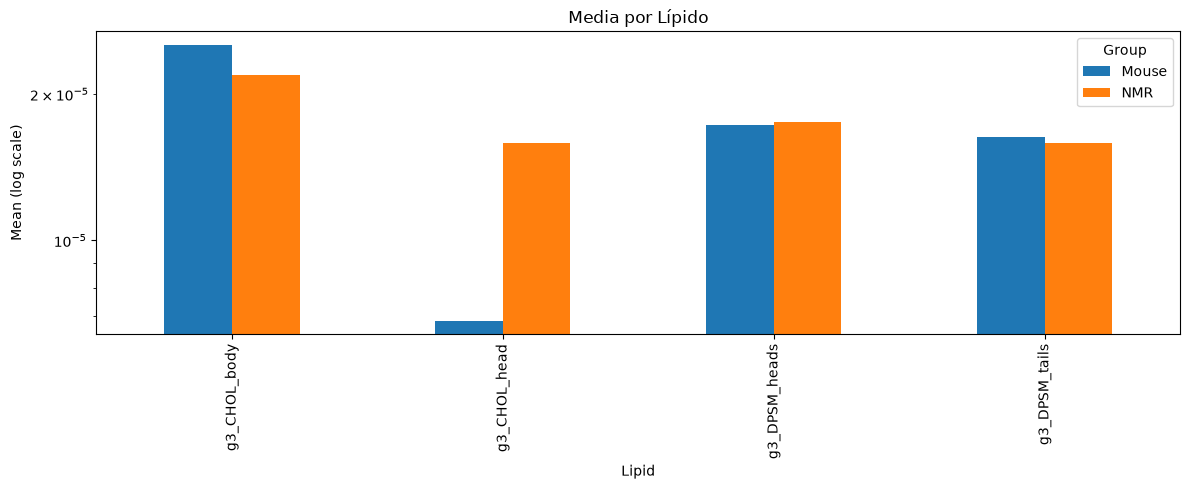

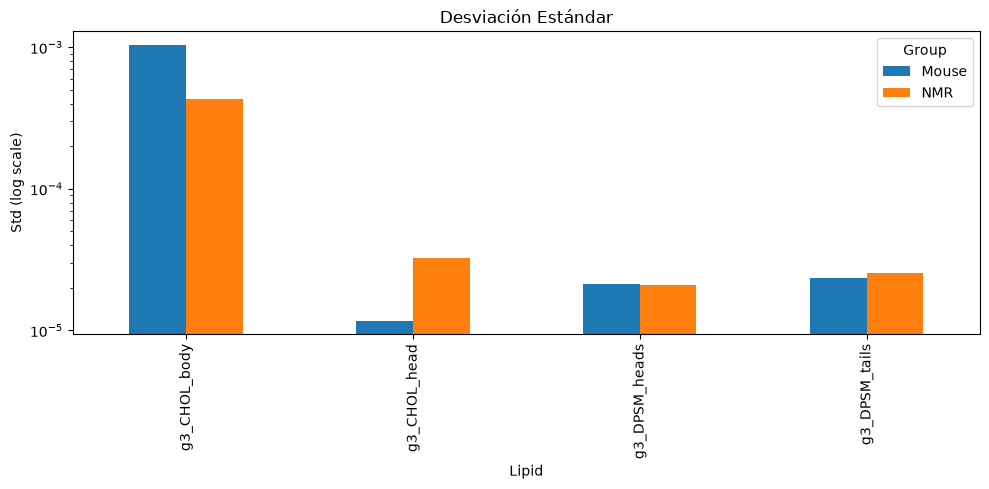

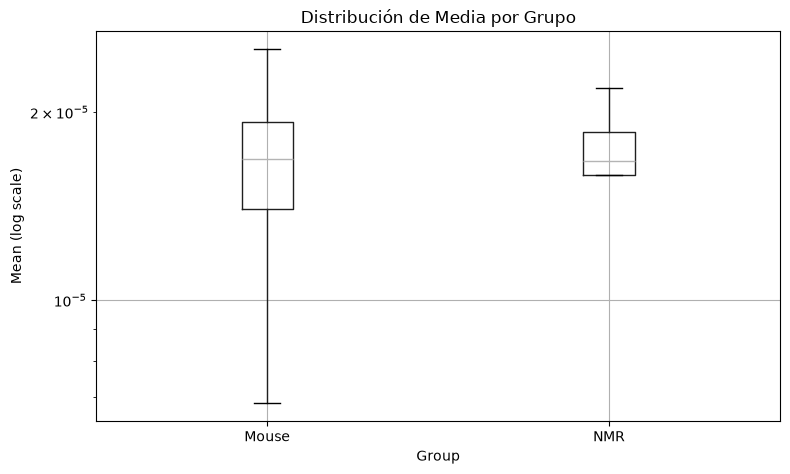

In [7]:
# Gráficas Datos 3D
# Gráfica 1: Media por lípido
df.pivot_table(values="Mean", index="Lipid", columns="Group").plot(
    kind="bar", figsize=(12, 5)
)
plt.title("Media por Lípido")
plt.ylabel("Mean (log scale)")
plt.yscale("log")
plt.tight_layout()
plt.savefig("../figures/mean.png", dpi=150, bbox_inches="tight")
plt.show()

# Gráfica 2: Desviación estándar
df.pivot_table(values="Std", index="Lipid", columns="Group").plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Desviación Estándar")
plt.ylabel("Std (log scale)")
plt.yscale("log")
plt.tight_layout()
plt.savefig("../figures/std.png", dpi=150, bbox_inches="tight")
plt.show()

# Gráfica 3: Distribución media por grupo
df.boxplot(column="Mean", by="Group", figsize=(8, 5))
plt.title("Distribución de Media por Grupo")
plt.ylabel("Mean (log scale)")
plt.yscale("log")
plt.suptitle("")
plt.tight_layout()
plt.savefig("../figures/boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

Los lípidos `g3_DPSM_heads` y `g3_DPSM_tails` presentan una media muy parecida en ambos grupos. En `g3_CHOL_body`, **Mouse** presenta media ligeramente mayor. Sin embargo, hay una diferencia evidente en `g3_CHOL_head` donde el grupo **NMR** tiene una media mucho más alta. Esta diferencia indica una concentración similar de lípidos en ambos grupos excepto en `g3_CHOL_head` donde la concentración para **Mouse** es sumamente menor al grupo **NMR**.

En la comparación de la desviación estándar igualmente en `g3_DPSM_heads` y `g3_DPSM_tails` podemos encontrar que ambos grupos son similares. Las mayores diferencias se encuentran entre los lípidos de colesterol: en `g3_CHOL_body`, **Mouse** presenta valores más altos mientras que en `g3_CHOL_head`, **NMR** es más alto. En `g3_CHOL_body` hay datos más variables (mayor desviación estándar).

La distribución de media por grupo muestra que el rango es más amplio para el grupo **Mouse**, indicando que los datos están más dispersos que **NMR**. No obstante, los datos son más simétricos en **Mouse**.

---

### Gráficas de lípidos (residuos)

In [8]:
# DataFrame stats resids
rows = []
for d in data:
    for lipid in data[d]:
        if lipid != "artificial_volume" and lipid.endswith("resids"):
            array = data[d][lipid]
            rows.append(
                {
                    "Group": d,
                    "Lipid": lipid,
                    "Size": array.size,
                    "Mean": np.mean(array),
                    "Median": np.median(array),
                    "Std": np.std(array),
                    "Min": np.min(array),
                    "Max": np.max(array),
                    "Q25": np.percentile(array, 25),
                    "Q75": np.percentile(array, 75),
                }
            )

df_resids = pd.DataFrame(rows)

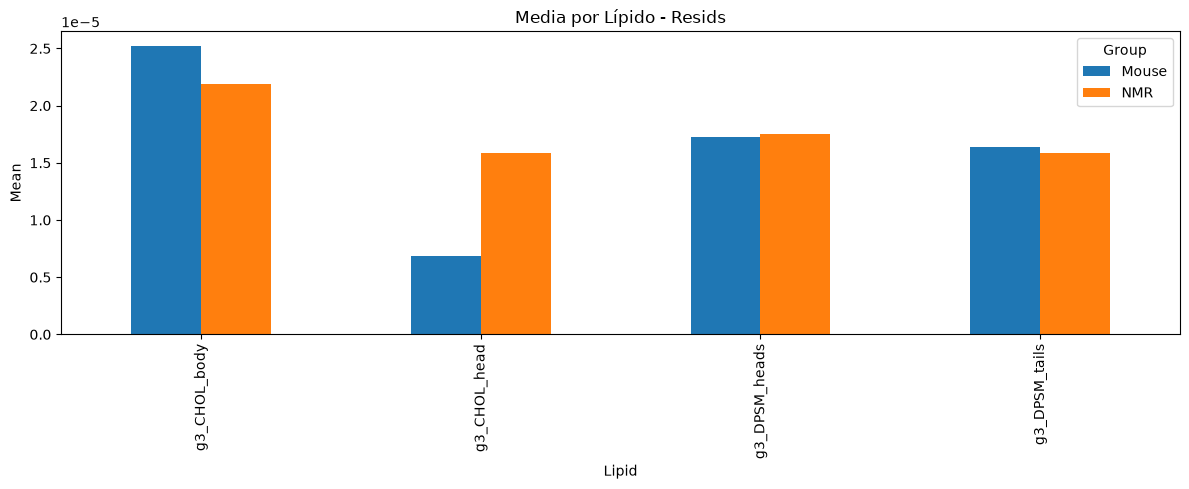

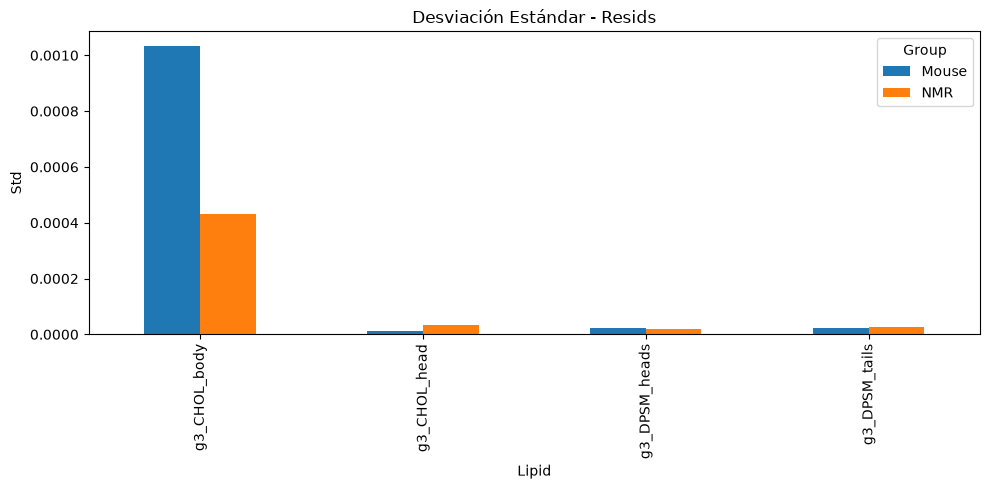

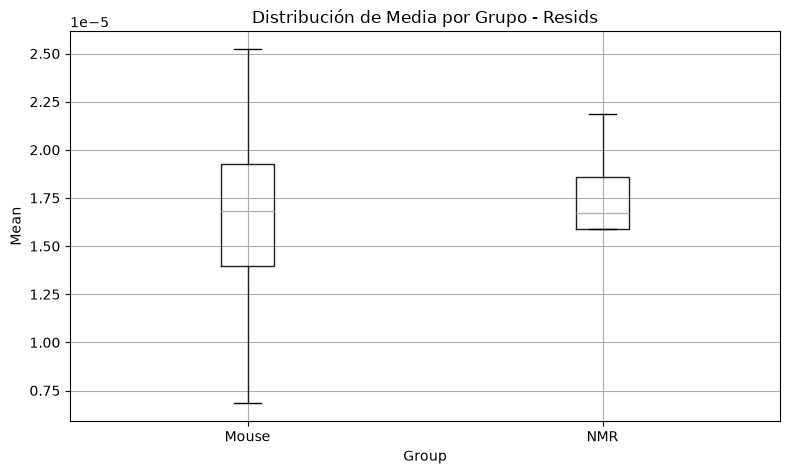

In [9]:
# Gráficas resids
# Gráfica 1: Media por lípido - Resids
df.pivot_table(values="Mean", index="Lipid", columns="Group").plot(
    kind="bar", figsize=(12, 5)
)
plt.title("Media por Lípido - Resids")
plt.ylabel("Mean")
plt.tight_layout()
plt.savefig("../figures/mean_resids.png", dpi=150, bbox_inches="tight")
plt.show()

# Gráfica 2: Desviación estándar - Resids
df.pivot_table(values="Std", index="Lipid", columns="Group").plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Desviación Estándar - Resids")
plt.ylabel("Std")
plt.tight_layout()
plt.savefig("../figures/std_resids.png", dpi=150, bbox_inches="tight")
plt.show()

# Gráfica 3: Distribución media por grupo - Resids
df.boxplot(column="Mean", by="Group", figsize=(8, 5))
plt.title("Distribución de Media por Grupo - Resids")
plt.ylabel("Mean")
plt.suptitle("")
plt.tight_layout()
plt.savefig("../figures/boxplot_resids.png", dpi=150, bbox_inches="tight")
plt.show()

Comparando los valores de la media por lípido para los residuos se puede ver que las gráficas son similares a la media de los datos 3D, solamente que en `g3_CHOL_head` para el grupo **Mouse** la media del residuo muestra un valor mayor que a la anterior gráfica.

Otra diferencia es en las desviaciones estándar para los residuos de lípidos. Las desviaciones estándar para `g3_CHOL_head`, `g3_DPSM_heads` y `g3_DPSM_tails` son cercanos a cero (<0.0002). De manera consistente con la gráfica anterior de desviaciones estándar, el grupo **Mouse** tiene una mayor variabilidad en los datos pero ahora la diferencia con el grupo **NMR** es ~2x.

Para la distribución media por grupo de los residuos la gráfica es similar a la distribución anterior, con la diferencia que los datos para el grupo **Mouse** son más simétricos (caja de dispersión).

---

### Volumen de caja
Para el volumen de caja (`artificial_volume`), el grupo **Mouse** tiene **18.7%** más volumen que **NMR**. Las densidades están normalizadas por volumen de caja.

In [10]:
pd.DataFrame({
    "Mouse_AV": data["Mouse"]["artificial_volume"],
    "NMR_AV": data["NMR"]["artificial_volume"]
})

,Mouse_AV,NMR_AV
0,1.052299e+06,886284.352608


In [11]:
(data["Mouse"]["artificial_volume"] - data["NMR"]["artificial_volume"]) / data["NMR"]["artificial_volume"] * 100

array([18.73150233])

---

### Estadísticas
En **Mouse**, `g3_CHOL_head` presenta la menor media entre los lípidos teniendo una distribución más dispersa. En `g3_CHOL_body` hay datos más variables (mayor desviación estándar).

In [12]:
# Mouse
df[df["Group"] == "Mouse"][["Lipid", "Mean", "Std"]].T

,0,1,2,3
Lipid,g3_DPSM_tails,g3_DPSM_heads,g3_CHOL_head,g3_CHOL_body
Mean,0.000016,0.000017,0.000007,0.000025
Std,0.000024,0.000021,0.000012,0.001034


Para **NMR**, las medias para cada lípido son muy similares. Se destaca únicamente, igual que en **Mouse**, `g3_CHOL_body` que tiene una desviación estándar más alta comparada con los otros lípidos.

In [13]:
# NMR
df[df["Group"] == "NMR"][["Lipid", "Mean", "Std"]].T

,4,5,6,7
Lipid,g3_DPSM_tails,g3_DPSM_heads,g3_CHOL_head,g3_CHOL_body
Mean,0.000016,0.000018,0.000016,0.000022
Std,0.000025,0.000021,0.000032,0.000432


In [14]:
def get_value(group, lipid, column="Mean"):
    return df[(df["Group"] == group) & (df["Lipid"] == lipid)][column].values[0]

comparisons = [
    ("Mouse", "g3_CHOL_head", "g3_CHOL_body", "CHOL head/body"),
    ("Mouse", "g3_DPSM_heads", "g3_DPSM_tails", "DPSM heads/tails"),
    ("NMR", "g3_CHOL_head", "g3_CHOL_body", "CHOL head/body"),
    ("NMR", "g3_DPSM_heads", "g3_DPSM_tails", "DPSM heads/tails"),
]

# RELACIÓN
print("RELACIÓN")
for group, lipid1, lipid2, label in comparisons:
    ratio = get_value(group, lipid1) / get_value(group, lipid2)
    print(f"Relación {group} {label}: {ratio}")

# DIFERENCIA
print("\n--------------")
print("DIFERENCIA")
for group, lipid1, lipid2, label in comparisons:
    diff = get_value(group, lipid1) - get_value(group, lipid2)
    print(f"Diferencia {group} {label}: {diff}")

# COEFICIENTE DE VARIACIÓN
print("\n--------------")
print("COEFICIENTE DE VARIACIÓN (Std/Mean)")
lipids_list = [
    ("Mouse", "g3_CHOL_head"),
    ("Mouse", "g3_CHOL_body"),
    ("Mouse", "g3_DPSM_heads"),
    ("Mouse", "g3_DPSM_tails"),
    ("NMR", "g3_CHOL_head"),
    ("NMR", "g3_CHOL_body"),
    ("NMR", "g3_DPSM_heads"),
    ("NMR", "g3_DPSM_tails"),
]
for group, lipid in lipids_list:
    cv = get_value(group, lipid, "Std") / get_value(group, lipid, "Mean")
    print(f"Coef.Var {group} {lipid}: {cv}")

RELACIÓN
Relación Mouse CHOL head/body: 0.27102591432047163
Relación Mouse DPSM heads/tails: 1.0557968361392474
Relación NMR CHOL head/body: 0.7256012612207168
Relación NMR DPSM heads/tails: 1.1037052107067948

--------------
DIFERENCIA
Diferencia Mouse CHOL head/body: -1.839509422226143e-05
Diferencia Mouse DPSM heads/tails: 9.125280571546951e-07
Diferencia NMR CHOL head/body: -5.999080833123369e-06
Diferencia NMR DPSM heads/tails: 1.6464028068698777e-06

--------------
COEFICIENTE DE VARIACIÓN (Std/Mean)
Coef.Var Mouse g3_CHOL_head: 1.715159835463001
Coef.Var Mouse g3_CHOL_body: 40.98304488226502
Coef.Var Mouse g3_DPSM_heads: 1.2401509271880595
Coef.Var Mouse g3_DPSM_tails: 1.44268417117492
Coef.Var NMR g3_CHOL_head: 2.048527361129254
Coef.Var NMR g3_CHOL_body: 19.742156834361108
Coef.Var NMR g3_DPSM_heads: 1.1872533301324992
Coef.Var NMR g3_DPSM_tails: 1.5925113045397306


**Relación**
* **Mouse**
    * **`CHOL` `head` / `body`**: La parte del denominador está más estructurada.
    * **`DPSM` `heads` / `tails`**: Tiene un lípido casi sin diferencia (uniforme).
* **NMR**
    * **`CHOL` `head` / `body`**: Parte del denominador más estructurada, pero más uniforme que en Mouse.
    * **`DPSM` `heads` / `tails`**: Tiene un lípido casi sin diferencia (uniforme).

**Diferencia**
* **Mouse**
    * **`CHOL` `head` - `body`**: Parte de `body` más densa.
    * **`DPSM` `heads` - `tails`**: Parte de `heads` más densa.
* **NMR**
    * **`CHOL` `head` - `body`**: Parte de `body` más densa; sin embargo, es mayor la diferencia en Mouse.
    * **`DPSM` `heads` - `tails`**: Parte de `heads` más densa; sin embargo, es mayor la diferencia en Mouse.

**Coeficiente de variación**
Ambos grupos presentan un coeficiente de variación extremo (CV > 100%).
* **`CHOL` `head`**: Existe alta variabilidad ~1.7-2.0x en ambos grupos.
* **`CHOL` `body`**: Variabilidad extrema para ambos grupos ~41-20x. Mouse tiene el doble de variabilidad que NMR.
* **`DPSM` `heads`**: Alta variabilidad ~1.2x en ambos grupos siendo la menor comparada con otros lípidos (~1.2x vs ~1.4-1.6x).
* **`DPSM` `tails`**: Alta variabilidad ~1.4-1.6x en ambos grupos.

---

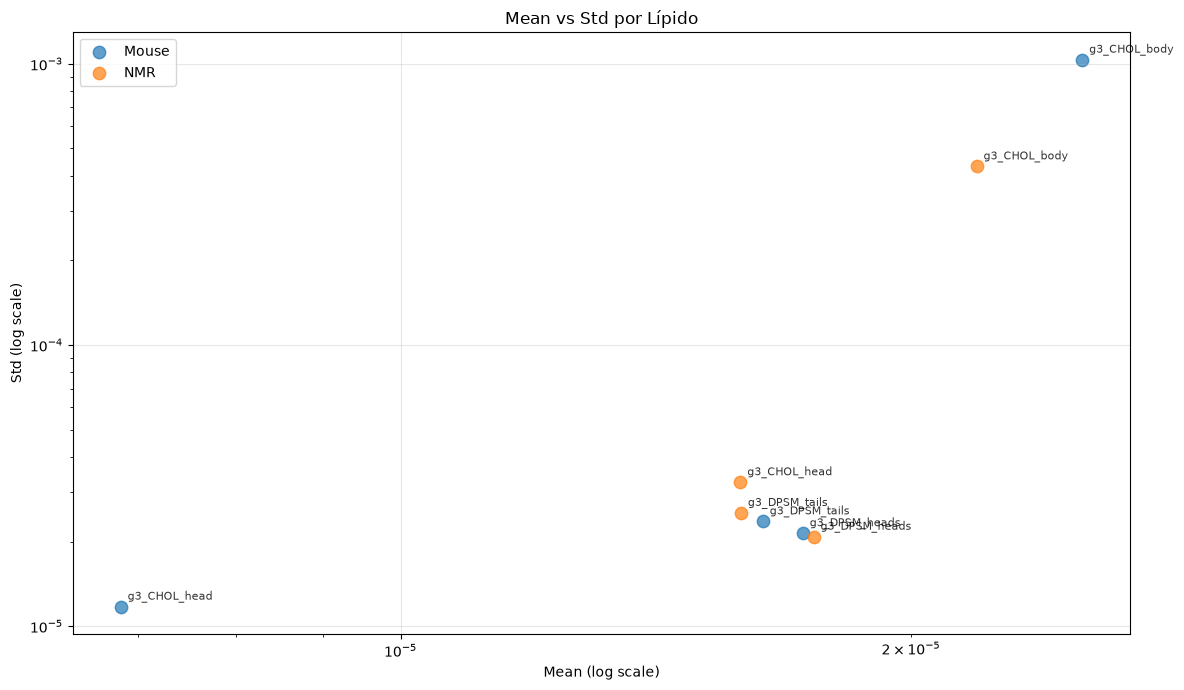

In [15]:
# Scatter plot: Mean vs Std, coloreando por grupo con etiquetas
plt.figure(figsize=(12, 7))
for group in df["Group"].unique():
    subset = df[df["Group"] == group]
    plt.scatter(subset["Mean"], subset["Std"], label=group, s=80, alpha=0.7)
    
    # Agregar etiquetas a cada punto
    for idx, row in subset.iterrows():
        plt.annotate(row["Lipid"], 
                    (row["Mean"], row["Std"]),
                    fontsize=8,
                    alpha=0.8,
                    xytext=(5, 5),
                    textcoords="offset points")

plt.xlabel("Mean (log scale)")
plt.ylabel("Std (log scale)")
plt.title("Mean vs Std por Lípido")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/scatter_mean_vs_std.png", dpi=150, bbox_inches="tight")
plt.show()

Se presenta un clúster de lípidos con valores Mean vs Std similares. Se destacan los lípidos de colesterol:
1. **`CHOL` `head`**: 
    * **Mouse**: Lípido con valores bajos (media y desviación estándar).
    * **NMR**: Media y desviación estándar más altos que Mouse.

2. **`CHOL` `body`**: El tipo de lípido tiene la mayor media y desviación estándar entre los demás, siendo esta característica más pronunciada en el grupo Mouse.

---

Se realizará una matriz de correlación. Sin embargo, solamente se realizará entre pares de los tipos de lípidos `CHOL` y `DPSM`:

In [16]:
# Verificar si hay misma forma

# Mouse
print(data["Mouse"]["g3_DPSM_heads"].shape == data["Mouse"]["g3_DPSM_tails"].shape)
print(data["Mouse"]["g3_CHOL_head"].shape == data["Mouse"]["g3_CHOL_body"].shape)

# NMR
print(data["NMR"]["g3_DPSM_heads"].shape == data["NMR"]["g3_DPSM_tails"].shape)
print(data["NMR"]["g3_CHOL_head"].shape == data["NMR"]["g3_CHOL_body"].shape)

True
True
True
True


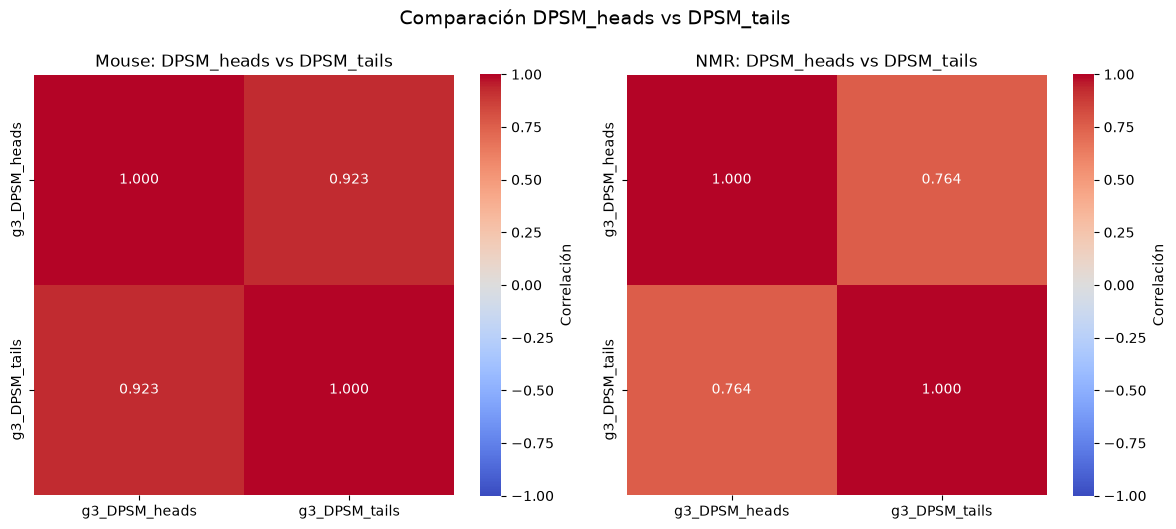

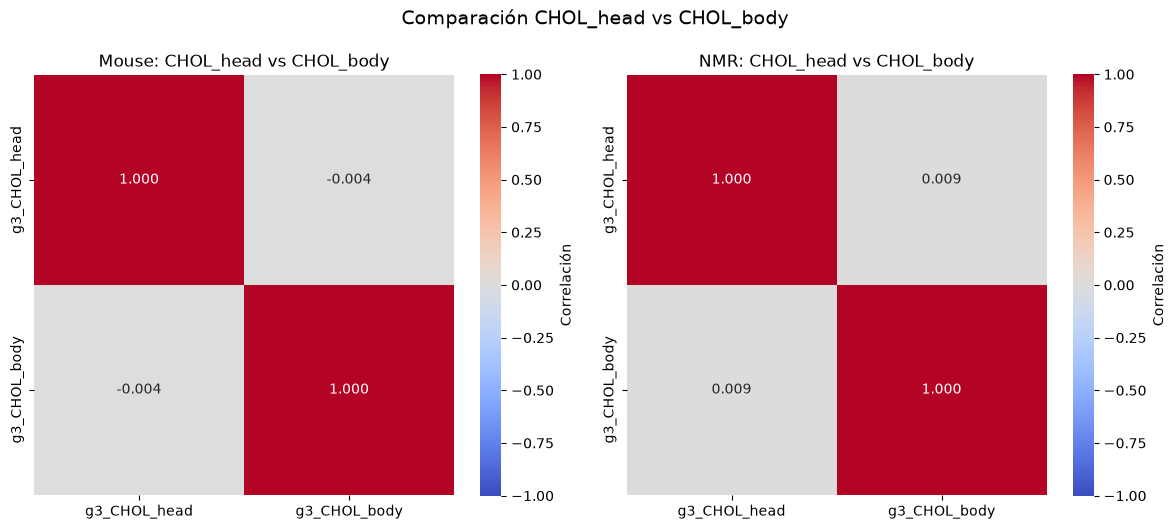

In [17]:
# Heatmap comparativo: Mouse vs NMR lado a lado
pairs = [
    ("g3_DPSM_heads", "g3_DPSM_tails"),
    ("g3_CHOL_head", "g3_CHOL_body")
]

for lipid1, lipid2 in pairs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for idx, group in enumerate(["Mouse", "NMR"]):
        # Verificar que tengan el mismo shape
        if data[group][lipid1].shape == data[group][lipid2].shape:
            # Aplanar y crear DataFrame
            df_pair = pd.DataFrame({
                lipid1: data[group][lipid1].flatten(),
                lipid2: data[group][lipid2].flatten()
            })
            
            # Calcular correlación
            corr = df_pair.corr()
            
            # Visualizar en subplot
            sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", 
                        center=0, vmin=-1, vmax=1, 
                        cbar_kws={"label": "Correlación"},
                        square=True, ax=axes[idx])
            axes[idx].set_title(f"{group}: {lipid1.replace('g3_', '')} vs {lipid2.replace('g3_', '')}")
    
    plt.suptitle(f"Comparación {lipid1.replace('g3_', '')} vs {lipid2.replace('g3_', '')}", 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f"../figures/heatmap_comparison_{lipid1}_{lipid2}.png", dpi=150, bbox_inches="tight")
    plt.show()

* **`DPSM` `heads` vs `DPSM` `tails`**: La correlación entre estos dos lípidos es alta en ambos grupos (**Mouse**: **0.923**, **NMR**: **0.764**).  Cuando la cabeza varía, la cola varía proporcionalmente.

* **`CHOL` `head` vs `CHOL` `body`**: La correlación es casi igual a cero (**Mouse**: **-0.004**, **NMR**: **0.009**). La cabeza y el cuerpo varían independientemente.

---

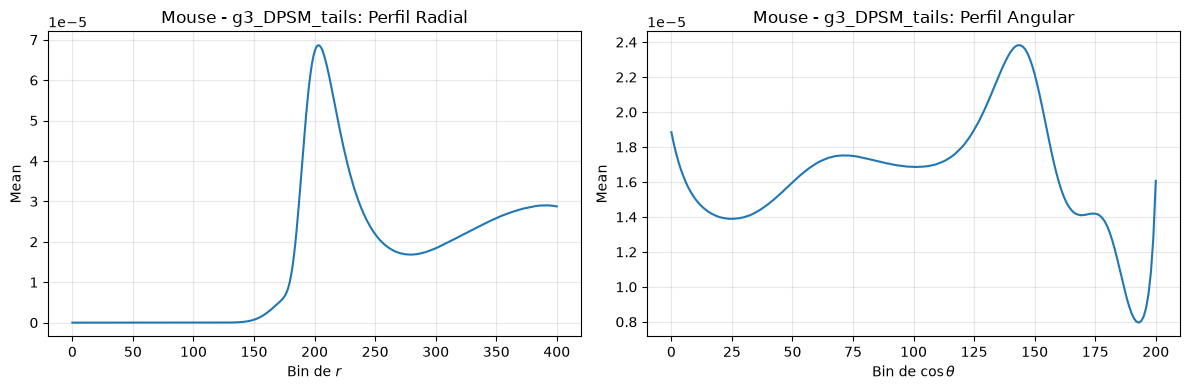

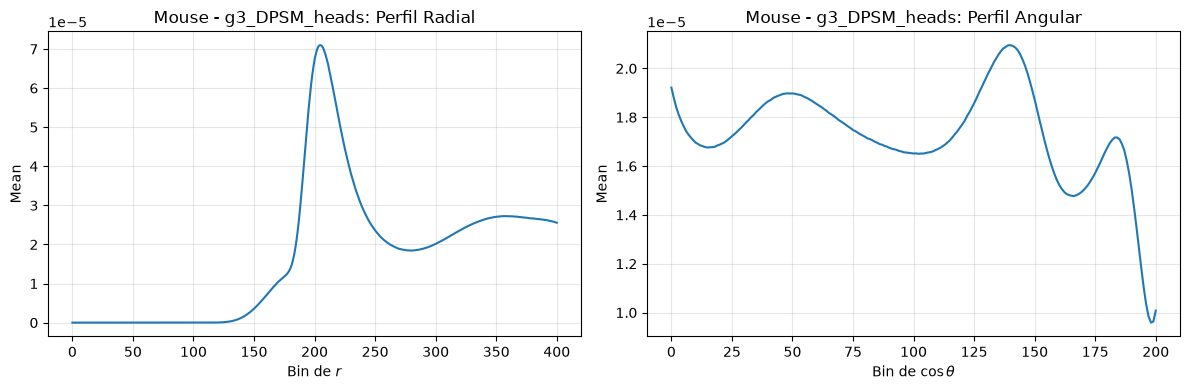

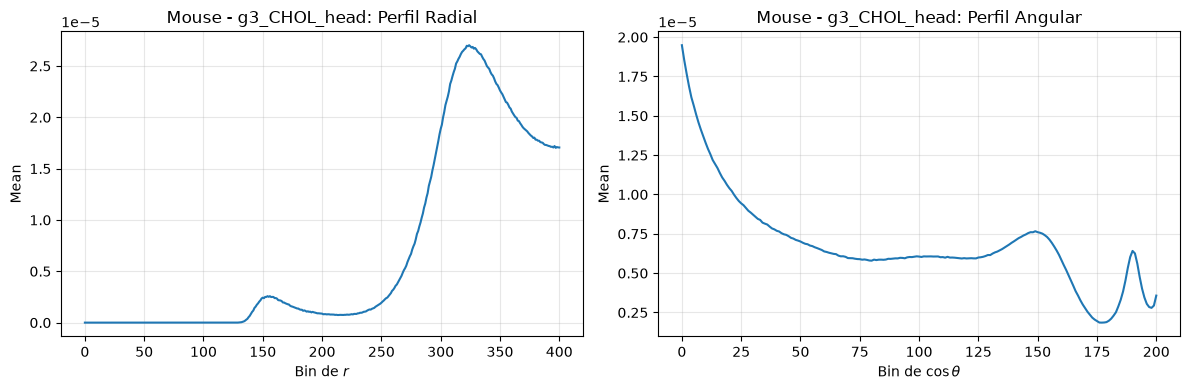

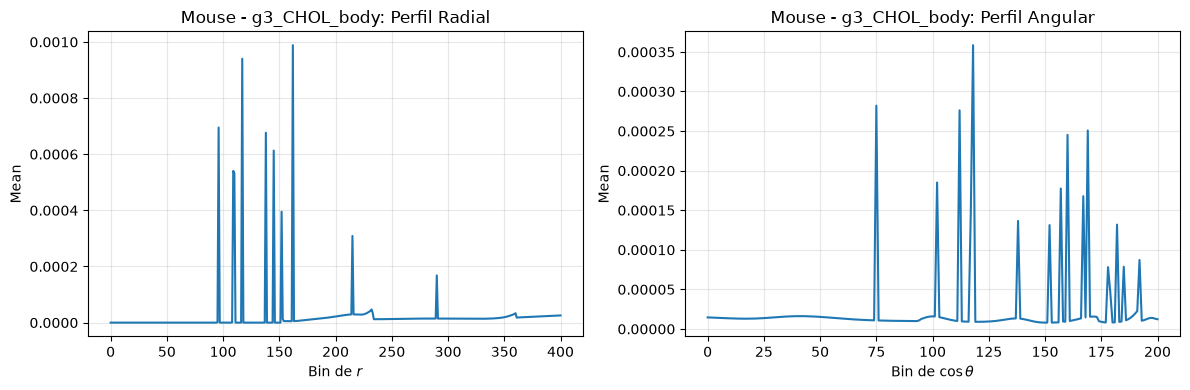

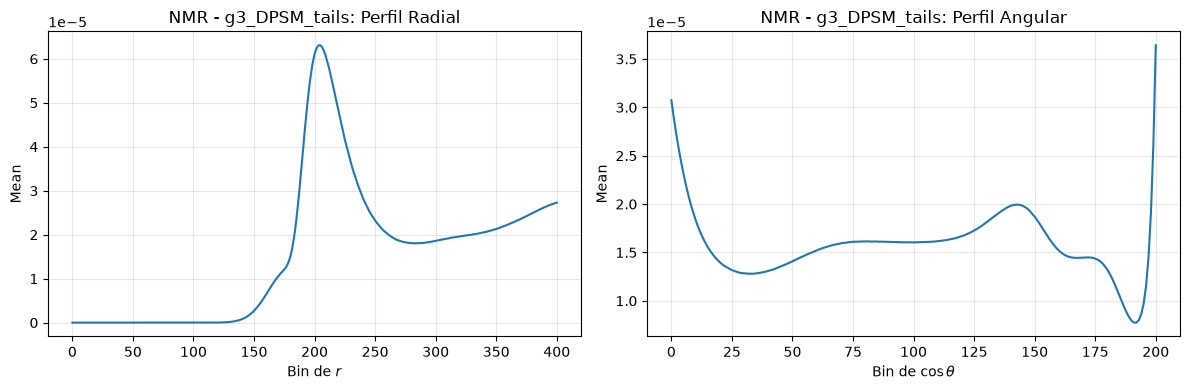

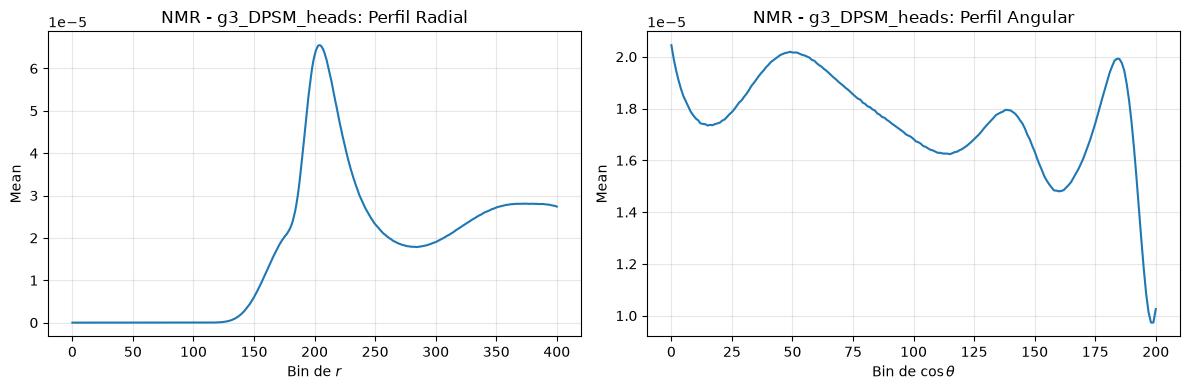

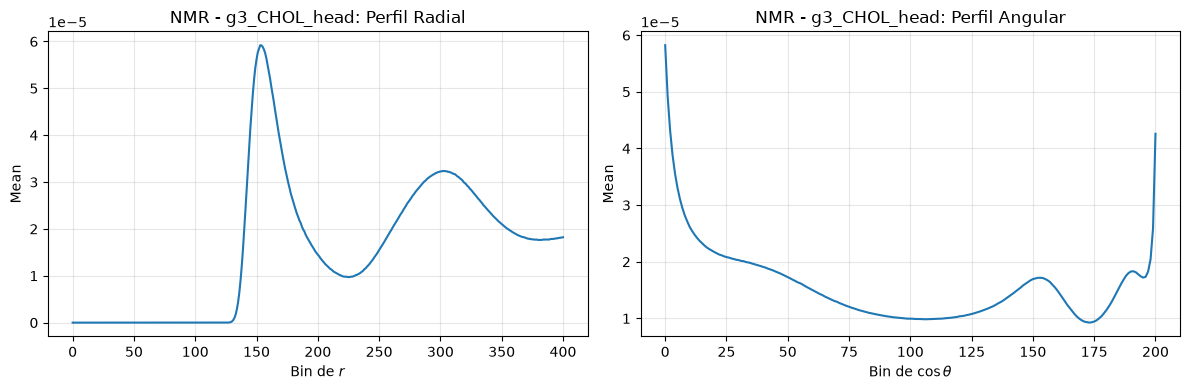

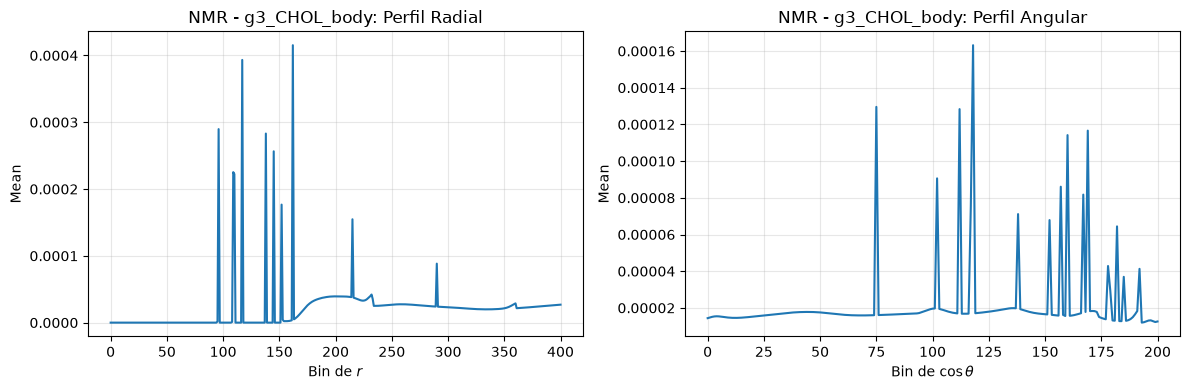

In [20]:
# Explorar variación espacial en dimensiones 3D: perfil radial vs perfil angular

for group in ["Mouse", "NMR"]:
    for lipid in data[group]:
        if lipid != "artificial_volume" and not lipid.endswith("resids"):
            array = data[group][lipid]
            
            # Perfil radial: promediando sobre el ángulo
            radial = np.mean(array, axis=(0, 2))
            
            # Perfil angular: promediando sobre las distancias
            angular = np.mean(array, axis=(0, 1))
            
            # Graficar perfil radial
            plt.figure(figsize=(12, 4))
            
            plt.subplot(1, 2, 1)
            plt.plot(radial)
            plt.title(f"{group} - {lipid}: Perfil Radial")
            plt.xlabel(r"Bin de $r$")
            plt.ylabel("Mean")
            plt.grid(True, alpha=0.3)
            
            # Graficar perfil angular
            plt.subplot(1, 2, 2)
            plt.plot(angular)
            plt.title(f"{group} - {lipid}: Perfil Angular")
            plt.xlabel(r"Bin de $\cos\theta$")
            plt.ylabel("Mean")
            plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig(f"../figures/3d_exploration_{group}_{lipid}.png", dpi=150, bbox_inches="tight")
            plt.show()

* **Mouse**
    * Perfil radial: Se presentan en los lípidos `DPSM` un perfil radial similar para `heads` y `tails`. Esta cambia para lípidos de colesterol, donde especialmente la variación del perfil en `body` es irregular.
    * Perfil angular: Igualmente los lípidos `DPSM` `heads` y `tails` tienen un perfil parecido. En lípidos de colesterol para `head` disminuye de ~2.0 a ~0.625 y posteriormente se mantiene constante a lo largo del resto del rango de $\cos\theta$, oscilando al final. En `body` podemos ver una similitud a su perfil radial, con la diferencia que se vuelve más irregular al incremento de pasos.

* **NMR**
    * Perfil radial: Los lípidos de tipo `DPSM` tienen un perfil similar. También el perfil radial del lípido de colesterol `head` tiene una variación parecida, con una cresta adicional. El perfil del lípido de colesterol `body` tiene una variación irregular.
    * Perfil angular: Los perfiles angulares para cada tipo de lípido difieren notablemente en este grupo. En `DPSM heads`, `DPSM tails` y `CHOL head` la media disminuye en el rango de bins x≈0-25, desde ~0.3 hasta ~6. En `DPSM heads` se observan 3 picos locales distribuidos en los pasos, indicando oscilaciones alrededor de la variación. El perfil de `CHOL body` presenta fluctuaciones abruptas, especialmente en x>75.

En ambos grupos, los lípidos de tipo `DPSM` presentan un perfil radial muy similar. Para colesterol solamente en `CHOL body` podemos ver que sí hay una similitud por la irregularidad entre el paso ~100-150. En cambio, para el perfil angular hay bastante diferencia en ambos grupos. También en `CHOL body` se puede ver mayor irregularidad para x>75.